# Which figure is right, and can you prove it?

**Week 1, Wednesday. Round 3 of 3: keep, drop or flag, the reconciliation, and Tuesday
recomputed.** By the end of this notebook you can make the three-way decision for a missing
value, defend keeping a large order that is real, prove a reconciliation in rows and in rupees,
draw the revenue bridge from the dashboard's figure to the books, and say what cleaning did to
Tuesday's finding.

> **The client asks.** "Which figure is right, how do you know, and can my analyst follow every
> decision you made? And tell Marketing whether Tuesday's finding survives."
>
> Anand Iyer, finance controller, Kalpa Retail

> **Kavya's review.** "Two reconciliations, not one: the rows and the rupees. Input equals clean
> plus rejected, in both. Then tell me what changed in Tuesday's story, including if it got
> smaller."

Round 2 kept 186 orders by the identity rule, set 15 rows aside with a reason each, and brought
Q1 to Rs 1,90,00,000. Two decisions are still open, and a third mistake is waiting at the end.

**Setup.** The helper, the two functions, and round 2's identity rule, so this notebook starts
from the 186 orders and the log of 15.

In [1]:
import sys, pathlib
here = pathlib.Path.cwd()
for parent in [here, *here.parents]:
    if (parent / "scripts" / "c2kit.py").exists():
        sys.path.insert(0, str(parent / "scripts")); break
import c2kit as kit

import csv, json

DATA = kit.data_dir()
ORDERS_CSV = DATA / "C2_W01_D03_orders_STUDENT.csv"

def read_orders(path=ORDERS_CSV):
    """Every row of an export as a dictionary of text, with the file line it came from."""
    with open(path, newline="", encoding="utf-8") as f:
        return [dict(row, line=n) for n, row in enumerate(csv.DictReader(f), start=2)]

def convert(value):
    """A whole number of rupees, or None with the reason, so a failure is counted, never hidden."""
    try:
        return int(value), ""
    except (TypeError, ValueError):
        return None, "amount does not convert to a whole number"

def identity_rule(rows):
    kept, log = {}, []
    for r in rows:
        value, _ = convert(r["amount"])
        k = r["order_id"]
        if k not in kept:
            kept[k] = r
        elif convert(kept[k]["amount"])[0] is None and value is not None:
            log.append((kept[k], "copy whose amount does not convert; its twin carries the value"))
            kept[k] = r
        else:
            log.append((r, "second copy of the order"))
    return list(kept.values()), log

raw = read_orders()
kept, dup_log = identity_rule(raw)
clean = [dict(r, amount=convert(r["amount"])[0]) for r in kept]
Q = lambda rows, q: sum(r["amount"] for r in rows if r["quarter"] == q)
print(len(clean), "orders from", len(raw), "rows; Q1", kit.rupees(Q(clean, "Q1")), "and Q2", kit.rupees(Q(clean, "Q2")))

186 orders from 201 rows; Q1 Rs 1,90,00,000 and Q2 Rs 1,87,00,000


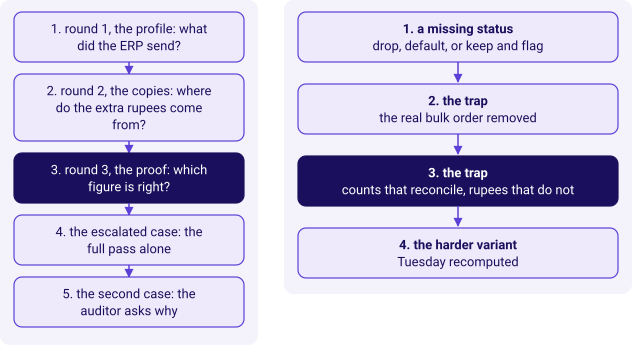

In [2]:
kit.side_by_side(
    kit.ladder(["round 1, the profile: what did the ERP send?", "round 2, the copies: where do the extra rupees come from?",
            "round 3, the proof: which figure is right?", "the escalated case: the full pass alone",
            "the second case: the auditor asks why"], lit=2, show=False),
    kit.vflow(["1. a missing status\ndrop, default, or keep and flag",
               "2. the trap\nthe real bulk order removed",
               "3. the trap\ncounts that reconcile, rupees that do not",
               "4. the harder variant\nTuesday recomputed"], lit=2, show=False),
)

## 1. A missing status: drop, default, or keep and flag

One order has no status. Every cleaning act is one of three decisions, and each moves a
different number: dropping moves revenue, a default invents a fact, and keep and flag leaves
revenue whole and keeps the order out of any count that needs its status.

**Predict before you run.** Revenue here is booked value, every order whatever its status, as
both the dashboard and the books count it. Which decision leaves Q2 revenue and the delivered
count both honest? a) drop the order; b) default the status to delivered; c) keep the order and
flag the status as unknown; d) default the status to cancelled.

decision,Q2 revenue,Q2 delivered orders,what it claims
drop the order,"Rs 1,86,98,150",57,the order never happened
default to delivered,"Rs 1,87,00,000",58,the order reached the customer
keep and flag,"Rs 1,87,00,000",57,the order happened; its fate is unknown


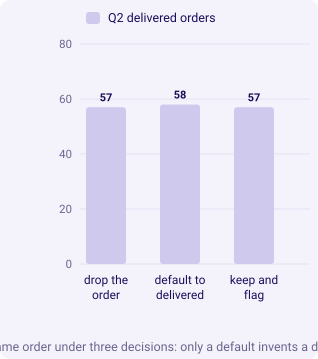

In [3]:
no_status = [r for r in clean if not r["status"]]
q2 = Q(clean, "Q2")
delivered = sum(1 for r in clean if r["quarter"] == "Q2" and r["status"] == "delivered")
options = [("drop the order", q2 - sum(r["amount"] for r in no_status), delivered),
           ("default to delivered", q2, delivered + len(no_status)),
           ("keep and flag", q2, delivered)]
kit.table(["decision", "Q2 revenue", "Q2 delivered orders", "what it claims"],
          [(d, kit.rupees(v), n, c) for (d, v, n), c in zip(options,
           ["the order never happened", "the order reached the customer", "the order happened; its fate is unknown"])])
kit.columns([d for d, _, _ in options], [("Q2 delivered orders", [n for _, _, n in options])],
            title="The same order under three decisions: only a default invents a delivery")

**What happened.** The answer is c. Dropping the order takes a booked order out of revenue that
Finance has in its books; defaulting to delivered adds a delivery nobody recorded. Keep and flag
leaves Q2 at Rs 1,87,00,000, keeps the delivered count at what the data can support, and writes
one line in the decisions log: which order, which field, what was decided and why.

In [4]:
decisions = [{"what": "status missing on one Q2 order", "decision": "keep and flag",
              "why": "revenue is booked value; the status is unknown, so the order stays out of status counts"}]
kit.check("exactly one order has no status", len(no_status) == 1)
kit.check("keep and flag leaves Q2 whole", options[2][1] == 18700000, kit.rupees(options[2][1]))

## 2. The trap: the real bulk order removed as an outlier

**The plausible wrong answer.** Sort Q2's orders and one sits far above the rest, 1.66 times the
next largest. The hurried analyst calls it an outlier, removes it "to be safe", and reports the
quarter without it.

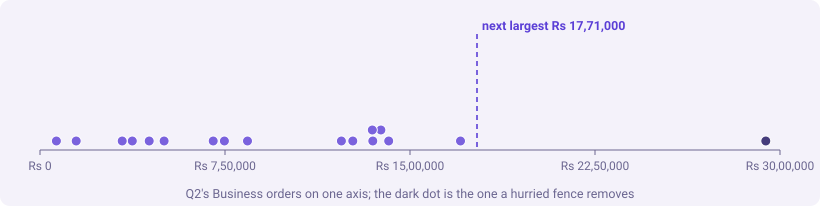

In [5]:
q2_orders = sorted((r for r in clean if r["quarter"] == "Q2"), key=lambda r: r["amount"], reverse=True)
top, runner_up = q2_orders[0], q2_orders[1]
q2_trimmed = Q(clean, "Q2") - top["amount"]
drop_trimmed = 1 - q2_trimmed / Q(clean, "Q1")
kit.strip([r["amount"] for r in q2_orders if r["segment"] == "Business"], lit=[0], lo=0, hi=3000000,
          markers=[("next largest", runner_up["amount"], "plain")],
          title="Q2's Business orders on one axis; the dark dot is the one a hurried fence removes")
kit.stats([(kit.rupees(q2_trimmed), "Q2 without it", "the hurried figure"),
           (f"{drop_trimmed:.1%}", "the drop", "Q1 1.90 crore to Q2 1.58 crore"),
           (f"{top['amount'] / runner_up['amount']:.2f}x", "the next largest", "why it looked wrong")])

**Why it is wrong.** Large is not wrong. Kalpa sells in bulk to corporate buyers through the
Business segment, where every order runs to lakhs, so a Business order at 29 lakh is the
business doing what it does. Removing it turns a 1.6 percent dip into a 17.1 percent collapse,
and Marketing would fund a rescue for a fall that never happened, while Finance, whose books hold
that order, would reject the whole reconciliation on sight. The check asks whether anything about
the record is wrong, not whether it is big: a valid id, a known Business customer with other
orders, every field converting.

In [6]:
buyer = top["customer_id"]
buyer_orders = [r for r in clean if r["customer_id"] == buyer]
business_min = min(r["amount"] for r in clean if r["segment"] == "Business")
kit.check("the largest Q2 order is a Business order", top["segment"] == "Business")
kit.check("its customer placed other orders in both quarters",
          {r["quarter"] for r in buyer_orders} == {"Q1", "Q2"}, f"{len(buyer_orders)} orders")
kit.check("Business orders never run below Rs 2 lakh", business_min >= 200000, kit.rupees(business_min))

**The fix.** Keep it, flag it, and show the quarter both ways, so nobody has to trust a removal
they cannot see. What changed: Q2 goes back from Rs 1,57,54,540 to Rs 1,87,00,000, and the drop
goes back from 17.1 percent to 1.6 percent.

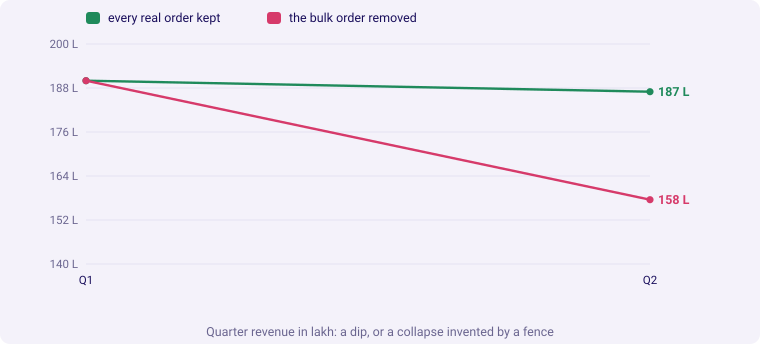

In [7]:
decisions.append({"what": "the largest Q2 order, a Business account with other orders",
                  "decision": "keep and flag", "why": "real revenue; shown with and without in the note"})
kit.line(["Q1", "Q2"], [("every real order kept", [Q(clean, "Q1") / 1e5, Q(clean, "Q2") / 1e5], "good"),
                        ("the bulk order removed", [Q(clean, "Q1") / 1e5, q2_trimmed / 1e5], "bad")],
         fmt=lambda v: f"{v:,.0f} L", lo=140, title="Quarter revenue in lakh: a dip, or a collapse invented by a fence")

> **Kavya's review.** "An outlier is a question about a record, never a reason to delete it.
> Check the record; if it is real, keep it and say so."

## 3. The trap: counts that reconcile while rupees do not

**The plausible wrong answer.** A second analyst builds the pass in the order that feels
natural: remove duplicate ids first, keeping the first copy, then convert amounts and reject the
ones that fail. The row count reconciles perfectly, and Q1 rounds to Finance's figure.

In [8]:
seen, first_copy, set_aside = set(), [], 0
for r in raw:
    if r["order_id"] in seen:
        set_aside += 1
        continue
    seen.add(r["order_id"])
    first_copy.append(r)
hurried = [dict(r, amount=convert(r["amount"])[0]) for r in first_copy if convert(r["amount"])[0] is not None]
rejected = set_aside + len(first_copy) - len(hurried)
q1_hurried = Q(hurried, "Q1")
kit.stats([(f"{len(raw)} = {len(hurried)} + {rejected}", "rows reconcile", "input equals clean plus rejected"),
           (kit.rupees(q1_hurried), "Q1", f"{q1_hurried / 1e7:.2f} crore, which reads as Finance's 1.9"),
           ("done", "the hurried verdict", "reconciled, ship it")])

**Why it is wrong.** Rounded to the crore, Rs 1,89,98,210 looks like 1.9. To the rupee it is
Rs 1,790 short of the books, because keeping the first copy kept the one whose amount could not
be read and set aside its twin, which carried the value. A count reconciliation proves only that
no row vanished; it cannot prove that the right rows stayed. Anand's analyst ties out to the rupee,
finds a booked order missing from a file you called reconciled, and stops trusting every other
decision in the log. The check is the second reconciliation, in rupees, against the books.

In [9]:
BOOKS_Q1 = 19000000   # Anand's Q1, which his analyst sends to the rupee
kit.check("the hurried rows reconcile", len(raw) == len(hurried) + rejected)
kit.check("the hurried Q1 misses the books by Rs 1,790", BOOKS_Q1 - q1_hurried == 1790,
          kit.rupees(BOOKS_Q1 - q1_hurried))
kit.check("the pass that converts first lands on the books", Q(clean, "Q1") == BOOKS_Q1)

**The fix.** Convert first, then apply the identity rule preferring the copy that validates, then
reconcile twice. Rows: 201 in equals 186 kept plus 15 set aside. Rupees: Q1 as exported minus
the rupees carried by the rows set aside equals the books. The bridge is that second
reconciliation drawn, and it is the page Anand's analyst will check.

**Predict before you run.** The bridge starts at Q1 as exported, Rs 2,09,98,210, and must land on
the books. How many moves does it need to get there? a) one, the duplicates; b) two, the
corporate copies and the consumer copies; c) three, adding the unreadable amount; d) none,
since the start already rounds to 2.1.

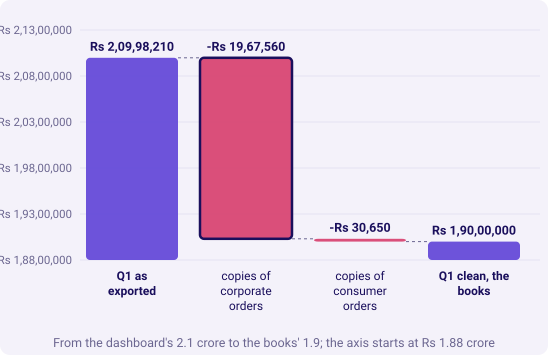

reconciliation,in,kept,set aside,holds
"rows, whole file",201,186,15,True
"rupees, Q1","Rs 2,09,98,210","Rs 1,90,00,000","Rs 19,98,210",True


In [10]:
exported_q1 = sum(convert(r["amount"])[0] or 0 for r in raw if r["quarter"] == "Q1")
q1_removed = [r for r, _ in dup_log if r["quarter"] == "Q1"]
corporate = -sum(convert(r["amount"])[0] or 0 for r in q1_removed if r["segment"] == "Business")
consumer = -sum(convert(r["amount"])[0] or 0 for r in q1_removed if r["segment"] != "Business")
kit.bridge(("Q1 as exported", exported_q1),
           [("copies of corporate orders", corporate), ("copies of consumer orders", consumer)],
           end_label="Q1 clean, the books", lit=(0,), lo=18800000,
           title="From the dashboard's 2.1 crore to the books' 1.9; the axis starts at Rs 1.88 crore")
kit.table(["reconciliation", "in", "kept", "set aside", "holds"],
          [("rows, whole file", len(raw), len(clean), len(dup_log), len(raw) == len(clean) + len(dup_log)),
           ("rupees, Q1", kit.rupees(exported_q1), kit.rupees(Q(clean, "Q1")), kit.rupees(-(corporate + consumer)),
            exported_q1 + corporate + consumer == Q(clean, "Q1"))])

**What happened.** The answer is b. The copies of two corporate orders carry Rs 19,67,560 and the
copies of the consumer orders carry Rs 30,650, and the bridge lands on Rs 1,90,00,000, the books,
to the rupee. The unreadable amount needs no move: it was never in the exported total, and its
twin, which was, stayed. What changed against the hurried pass: one Retail-Plus order and its
Rs 1,790 are back, and both reconciliations hold.

In [11]:
kit.check("the bridge lands on the books", exported_q1 + corporate + consumer == BOOKS_Q1)
kit.check("the rows reconcile", len(raw) == len(clean) + len(dup_log))
decisions.append({"what": "15 rows sharing an order_id with another row", "decision": "set aside",
                  "why": "identity rule on order_id; the copy that validates stays"})
kit.table(["what", "decision", "why"], [(d["what"], d["decision"], d["why"]) for d in decisions],
          caption="The decisions log, so every act can be followed")

what,decision,why
status missing on one Q2 order,keep and flag,"revenue is booked value; the status is unknown, so the order stays out of status counts"
"the largest Q2 order, a Business account with other orders",keep and flag,real revenue; shown with and without in the note
15 rows sharing an order_id with another row,set aside,identity rule on order_id; the copy that validates stays


## 4. The harder variant: Tuesday recomputed on clean data

Tuesday told the leadership group that revenue fell about 11 percent from Q1 to Q2 and that
Retail-Plus orders per customer fell 49 percent, from 2.32 to 1.18. Both numbers were measured on
the export as delivered. The honest analyst recomputes and reports what changed, including if the
finding got smaller.

**Predict before you run.** On clean data, what happens to Tuesday's Retail-Plus finding?
a) it disappears, since the duplicates caused it; b) it survives, smaller; c) it grows, since
clean data sharpens it; d) it moves to Retail-Core.

segment,Tuesday Q1,Tuesday Q2,Tuesday change,clean Q1,clean Q2,clean change
Retail-Core,1.12,1.06,-5.3%,1.09,1.06,-2.7%
Retail-Plus,2.32,1.18,-49.0%,1.82,1.18,-35.0%
Business,1.82,1.55,-15.0%,1.64,1.55,-5.6%
Student,2.5,3.5,+40.0%,2.5,3.5,+40.0%


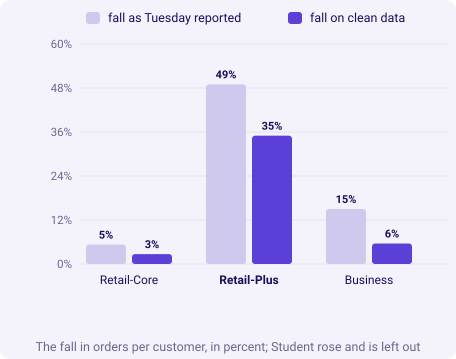

In [12]:
def per_customer(rows, q, seg):
    rs = [r for r in rows if r["quarter"] == q and r["segment"] == seg]
    return len(rs) / len({r["customer_id"] for r in rs})

segs = ["Retail-Core", "Retail-Plus", "Business", "Student"]
tuesday = {"Retail-Core": (1.12, 1.06, -5.3), "Retail-Plus": (2.32, 1.18, -49.0),
           "Business": (1.82, 1.55, -15.0), "Student": (2.50, 3.50, 40.0)}
dirty = [tuesday[s][2] for s in segs]
cleaned = [round(100 * (per_customer(clean, "Q2", s) / per_customer(clean, "Q1", s) - 1), 1) for s in segs]
kit.table(["segment", "Tuesday Q1", "Tuesday Q2", "Tuesday change", "clean Q1", "clean Q2", "clean change"],
          [(s, tuesday[s][0], tuesday[s][1], f"{d:+.1f}%", round(per_customer(clean, "Q1", s), 2),
            round(per_customer(clean, "Q2", s), 2), f"{c:+.1f}%") for s, d, c in zip(segs, dirty, cleaned)],
          caption="Orders per customer, Q1 to Q2: as Tuesday reported it, and on clean data")
kit.columns(segs[:3], [("fall as Tuesday reported", [-d for d in dirty[:3]]), ("fall on clean data", [-c for c in cleaned[:3]])],
            fmt=lambda v: f"{v:.0f}%", lit=(1,), title="The fall in orders per customer, in percent; Student rose and is left out")

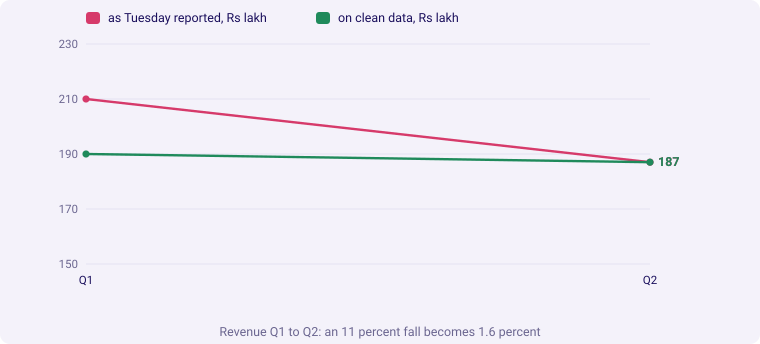

In [13]:
rev_dirty = 1 - 18700000 / 21000000
rev_clean = 1 - Q(clean, "Q2") / Q(clean, "Q1")
kit.line(["Q1", "Q2"], [("as Tuesday reported, Rs lakh", [210.0, 187.0], "bad"),
                        ("on clean data, Rs lakh", [Q(clean, "Q1") / 1e5, Q(clean, "Q2") / 1e5], "good")],
         fmt=lambda v: f"{v:,.0f}", lo=150, title="Revenue Q1 to Q2: an 11 percent fall becomes 1.6 percent")
kit.check("Retail-Plus still falls on clean data", cleaned[1] < -30, f"{cleaned[1]:+.1f}%")
kit.check("the Retail-Plus fall is smaller than Tuesday reported", cleaned[1] > dirty[1])
kit.check("the revenue drop shrinks to under 2 percent", rev_clean < 0.02, f"{rev_clean:.1%} against {rev_dirty:.1%}")

**What happened.** The answer is b. Retail-Plus orders per customer fall 35.0 percent on clean
data, from 1.82 to 1.18, against the 49 percent Tuesday reported: the finding stands, smaller,
because most of the migration's copies sat in Retail-Plus in Q1. The revenue drop shrinks from
11.0 percent to 1.6 percent. Both go in the note, the smaller numbers first, because a finding that
shrank and was reported honestly is worth more to Marketing than one that was never checked.

**The note to Finance, in under 120 words.** "Anand, your 1.9 crore is right. The ERP export
counted fifteen rows twice, fourteen of them in Q1; two copies of corporate orders carry
Rs 19,67,560 of the Rs 19,98,210 difference. Rows reconcile, 201 received equals 186 kept plus
15 set aside, and rupees reconcile to your books exactly. Every row set aside and every decision
is in the attached log. Two things we kept and flagged: one Q2 order with no status, and the
largest Q2 order, a real Business account. On clean data the Q1 to Q2 drop is 1.6 percent, not 11,
and the Retail-Plus frequency fall is 35 percent, not 49. It survives, smaller."

### In the interview

**[S] Finance and your dashboard disagree; what do you do?** "I assume nobody is lying and
both numbers are computed correctly from different inputs, so I find the difference rather than
pick a side. I get Finance's figure to the rupee and its definition, profile my source, and build a
bridge from my number to theirs, one move per cause, each move backed by the rows that carry it.
I reconcile twice, in rows and in rupees. When the bridge closes, I say which figure is right and
why, fix the source, and recompute anything that was reported from the wrong number."

**[D] An auditor asks why you dropped 14 rows; walk them through it.** "They were not dropped;
they were set aside, and each is in the log. Fourteen Q1 rows share an order id with another row.
The identity rule is the order id, because the ERP issues one per order. For each pair I kept
the copy whose fields validate, and I can show the rupees: two corporate copies carry
Rs 19,67,560 and the rest Rs 30,650. The rows reconcile, 114 Q1 rows in and 100 kept, and the
rupees bridge to your books exactly."

**[S] How do you handle outliers?** "I sort and look at the tail, then ask whether the record is
wrong, not whether it is big. A valid id, a real account and fields that convert make it
revenue. I keep it, flag it, and show the result with and without it, so the reader sees how much
one record carries."

### Depth: why reconcile in both units

A count reconciliation proves no row vanished, and a rupee reconciliation proves the right value
stayed. Each catches what the other cannot: this morning's hurried pass reconciled in rows and
lost Rs 1,790, and a pass that swapped one kept order for another of the same value would
reconcile in rupees and hide the swap in the rows. Finance teams reconcile control totals in both
units for exactly that reason.

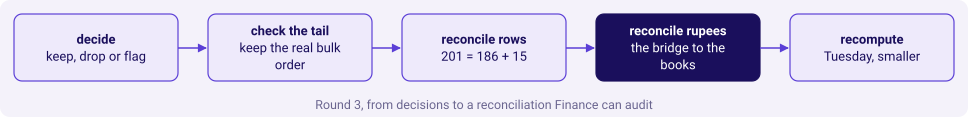

What round 3 established,The number
"Q1 clean, equal to the books","Rs 1,90,00,000"
"Q2 clean, every real order kept","Rs 1,87,00,000"
Revenue change Q1 to Q2,"-1.6%, not -11.0%"
Retail-Plus orders per customer,"1.82 to 1.18, -35.0%, not -49.0%"
Decisions in the log,3


In [14]:
kit.flow(["decide\nkeep, drop or flag", "check the tail\nkeep the real bulk order",
          "reconcile rows\n201 = 186 + 15", "reconcile rupees\nthe bridge to the books",
          "recompute\nTuesday, smaller"], lit=3,
         title="Round 3, from decisions to a reconciliation Finance can audit")
kit.table(["What round 3 established", "The number"],
          [("Q1 clean, equal to the books", kit.rupees(Q(clean, "Q1"))),
           ("Q2 clean, every real order kept", kit.rupees(Q(clean, "Q2"))),
           ("Revenue change Q1 to Q2", f"-{rev_clean:.1%}, not -{rev_dirty:.1%}"),
           ("Retail-Plus orders per customer", "1.82 to 1.18, -35.0%, not -49.0%"),
           ("Decisions in the log", str(len(decisions)))])

In [15]:
kit.check_summary()
print("Next: the escalated case runs the whole pass alone; Thursday asks whether the smaller Retail-Plus fall is real.")

Next: the escalated case runs the whole pass alone; Thursday asks whether the smaller Retail-Plus fall is real.
